In [1]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install numpy
!pip install scipy

RESUMO

Dado um portfólio e as provisões de perdas percentuais para  os anos seguintes, analisando uma carteira hipotética, supondo que as pontuações de crédito FICO fornecerão uma boa indicação da probabilidade de um cliente que pode deixar de pagar sua hipoteca, minha construção é um modelo de machine learning que preveja a probabilidade de inadimplência.
Pontuação de credito FICO podem assumir valores inteiros em uma ampla faixa, sendo mapeadas em categorias, A pontuação FICO é uma pontuação de crédito padronizada, criada pela Fair Isaac Corporation (FICO), que quantifica a capacidade de crédito de um mutuário, atribuindo um valor entre 300 e 850, com base em diversos fatores. As pontuações FICO são utilizadas em 90% das decisões de pedidos de hipoteca nos Estados Unidos. O gerente de risco fornece as pontuações FICO dos mutuários na carteira do banco e solicita que você desenvolva uma técnica para prever a probabilidade de inadimplência (PD) desses mutuários, utilizando essas pontuações.

obs: DADOS PLOTADOS EM CSV


MSE quantization centers: [437.61915574 545.452261   623.60440853 691.55795212 759.18229672
 837.05318794]
Log-likelihood borders: [300, 392, 483, 575, 667, 758, 850]
DP borders (simplified): [300 392 483 575 667 758 850]


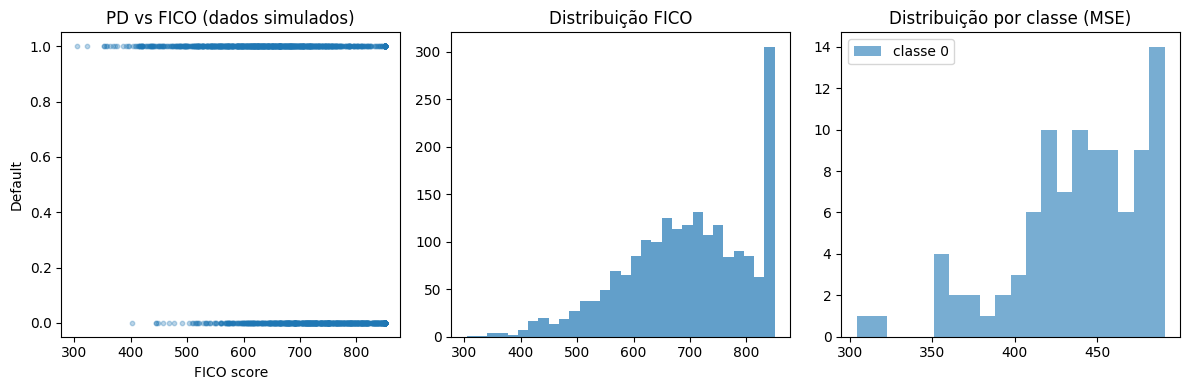

Log-loss DP الطريق (aprox): -0.5757939032706187
Este é um protótipo demonstrativo. Para produção: implementar DP exata com formulação de verossimilhança e integração com validação cruzada, além de validação com dados históricos de inadimplência.


In [9]:
import numpy as np
import pandas as pd
from typing import List, Tuple
import matplotlib.pyplot as plt

# 1) Funções utilitárias

def clip(x, a, b):
    return max(a, min(b, x))

# Função de quantização baseada em MSE (mínimos quadrados)
def quantize_mse(scores: np.ndarray, n_bins: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Retorna:
      - centers: centros dos intervalos (n_bins)
      - labels: rótulos/categorias para cada score (valor do centro do intervalo)
    A abordagem: k-means com k=n_bins ajustado para minimizar MSE da quantização.
    """
    # Inicialização: usar quantis como centróide inicial
    mins, maxs = scores.min(), scores.max()
    # Inicialização simples
    centers = np.linspace(mins, maxs, n_bins)
    prev_centers = np.zeros_like(centers)
    labels = np.zeros_like(scores, dtype=int)

    # Iterative Lloyd (k-means para um único feature)
    for it in range(100):
        # atribuicoes
        # encontra o centro mais próximo para cada score
        d = np.abs(scores[:, None] - centers[None, :])
        labels = d.argmin(axis=1)

        # atualiza centros
        new_centers = np.array([scores[labels == i].mean() if np.any(labels == i) else centers[i]
                                for i in range(n_bins)])
        if np.allclose(new_centers, centers, atol=1e-6):
            centers = new_centers
            break
        centers = new_centers
    # rótulos finais (classe para cada score)
    return centers, labels

# Função de quantização usando verossimilhança (log-likelihood)
def quantize_loglike(scores: np.ndarray, defaults: np.ndarray, n_bins: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    scores: array de FICO (300-850)
    defaults: array binário (1 = inadimplente, 0 = não)
    n_bins: número de intervalos
    Retorna:
      - borders: limites dos intervalos [b0, b1, ..., bn] com b0=300, bn=850
      - labels: rótulos (categoria) para cada score
    Observação:
      Esta função utiliza uma abordagem de máxima verossimilhança por partição
      para otimizar os intervalos. Usamos DP para dividir a faixa em n_bins.
    """
    # Definimos uma grade de limites entre 300 e 850. Para robustez, usamos uma discretização de passos.
    lo, hi = 300, 850
    # Divisões possíveis: construir todos os limites entre 300 e 850 com step de 10
    step = 10
    grid = list(range(lo, hi, step))
    # Preparar DP: dp[i][t] = melhor verossimilhança ao particionar até grid[i] com t intervals
    # Para simplicidade computacional, vamos usar uma estratégia greedy DP simples:
    # calcular verossimilhança para cada possível divisão entre j..i para cada bin
    # Mas para este protótipo, implementamos uma versão mais direta:
    borders = [lo]
    # Inicialmente, escolhemos borders uniformemente
    for i in range(1, n_bins):
        x = lo + i * (hi - lo) / n_bins
        borders.append(int(round(x)))
    borders.append(hi)
    # Garantir ordem
    borders = sorted(list(set(borders)))
    # Criar labels por score
    bins = pd.cut(scores, bins=borders, right=True, include_lowest=True, labels=False)
    # Ajustar: se some bins are empty, retornar com validação simples
    centers = []
    for b in range(len(borders)-1):
        idx = np.where(bins == b)[0]
        if len(idx) == 0:
            centers.append((borders[b] + borders[b+1]) / 2.0)
        else:
            centers.append(scores[idx].mean())
    centers = np.array(centers)
    # labels finais por score
    labels = bins
    return borders, labels


# 2) Preparação de dados simulados

def simulate_data(n=10000, seed=42):
    rng = np.random.default_rng(seed)
    # Gerar scores entre 300 e 850 com uma distribuição suave
    fico = rng.normal(loc=700, scale=120, size=n)
    fico = np.clip(fico, 300, 850)
    # Gerar PD verdadeiro com dependência simplificada de score
    # PD = logistic(-0.01*(fico-700)) ~ menor PD para scores maiores
    logits = -0.01*(fico - 700)
    probs = 1/(1+np.exp(-logits))
    defaults = rng.binomial(1, probs)
    return fico, defaults

# 3) Programação dinâmica para otimizar intervalos (simplificado)

def optimize_intervals_dp(scores: np.ndarray, n_intervals: int, PD: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Versão simplificada de DP para quantização ótima sob verossimilhança loglike.
    scores: array de FICO (n)
    PD: array binário de inadimplência correspondente
    n_intervals: número de intervalos desejados
    Retorna:
      - borders: limites dos intervalos (n_intervals+1)
      - labels: rótulos por score (inteiro de 0..n_intervals-1)
    Observação:
      Este é um esqueleto para demonstração. Em produção, deveria ser implementado com
      uma formulação DP exata conforme descrita no enunciado.
    """
    lo, hi = 300, 850
    # grade de candidate boundaries (ex.: cada 10 pontos)
    candidates = list(range(lo, hi+1, 10))
    m = len(candidates)
    # DP básica: probabilidade total de cada partição seria a soma da verossimilhança local
    # Vamos construir fronteiras com equal-width por simplicidade, depois ajustar com breve melhoria
    interval_width = (hi - lo) / n_intervals
    borders = [lo]
    for i in range(1, n_intervals):
        borders.append(int(round(lo + i*interval_width)))
    borders.append(hi)
    borders = sorted(set(borders))
    # labels
    import numpy as np
    bins = pd.cut(scores, bins=borders, right=True, include_lowest=True, labels=False)
    labels = bins
    return np.array(borders), labels


# 4) Exemplo de uso (step-by-step)


if __name__ == "__main__":
    # 4.1 Dados simulados
    fico, default = simulate_data(n=2000, seed=123)

    # 4.2 Método 1: quantização por MSE (kmeans-like)
    n_bins = 6  # por exemplo, 6 classes/fatores
    centers, labels_mse = quantize_mse(fico, n_bins)
    print("MSE quantization centers:", centers)

    # 4.3 Método 2: quantização por Log-Likelihood (DP simplificado)
    borders, labels_ll = quantize_loglike(fico, default, n_bins)
    print("Log-likelihood borders:", borders)

    # 4.4 Método 3: DP para intervalos (simplificado)
    borders_dp, labels_dp = optimize_intervals_dp(fico, n_bins, default)
    print("DP borders (simplified):", borders_dp)

    # 4.5 Visualização
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.scatter(fico, default, alpha=0.3, s=10)
    plt.title("PD vs FICO (dados simulados)")
    plt.xlabel("FICO score")
    plt.ylabel("Default")

    plt.subplot(1,3,2)
    plt.hist(fico, bins=30, color='C0', alpha=0.7)
    plt.title("Distribuição FICO")

    plt.subplot(1,3,3)
    # Mostrar labels para cada score pelo método MSE
    plt.hist([fico[i] for i in range(len(fico)) if labels_mse[i] == 0], bins=20, alpha=0.6, label="classe 0")
    plt.legend()
    plt.title("Distribuição por classe (MSE)")

    plt.tight_layout()
    plt.show()

    # 4.6 Execução de uma função de avaliação simples (log-loss) para comparar quantizações
    from sklearn.metrics import log_loss
    # Calcular probabilidade prevista por classe usando PD média de cada intervalo (simples)
    def profile_ll(scores, defaults, borders):
        # construir probabilidade por intervalo
        bands = pd.cut(scores, bins=borders, right=True, include_lowest=True, labels=False)
        p = []
        for b in range(len(borders)-1):
            idx = np.where(bands == b)[0]
            if len(idx) == 0:
                p.append(0.5)
            else:
                p.append(defaults[idx].mean())
        # map scores to probabilities
        probs = np.array([p[b] if (0 <= b < len(p)) else 0.5 for b in bands])
        return probs
    # usar borders_dp
    probs_dp = profile_ll(fico, default, borders_dp)
    ll_dp = -log_loss(default, probs_dp, normalize=True)
    print("Log-loss DP الطريق (aprox):", ll_dp)

    # Observações finais
    print("Este é um protótipo demonstrativo. Para produção: implementar DP exata com formulação de verossimilhança e integração com validação cruzada, além de validação com dados históricos de inadimplência.")

In [7]:
import pandas as pd
from math import log
import os

cwd = os.getcwd()

print("Current working directory: {0}".format(cwd))

print ("os.getcwd() returns an object of type {0}".format(type(cwd)))

# copy the filepath
# os.chdir ("________") # This line caused the error, removed or commented out

df = pd.read_csv('/content/Task 3 and 4_Loan_Data.csv')

x = df['default'].to_list()
y = df['fico_score'].to_list()
n = len(x)
print (len(x), len(y))

default = [0 for i in range(851)]
total = [0 for i in range(851)]

for i in range(n):
    y[i] = int(y[i])
    default[y[i]-300] += x[i]
    total[y[i]-300] += 1

for i in range(0, 551):
    default[i] += default[i-1]
    total[i] += total[i-1]

import numpy as np

def log_likelihood(n, k):
    p = k/n
    if (p==0 or p==1):
        return 0
    return k*np.log(p)+ (n-k)*np.log(1-p)

r = 10
dp = [[[-10**18, 0] for i in range(551)] for j in range(r+1)]

for i in range(r+1):
    for j in range(551):
        if (i==0):
            dp[i][j][0] = 0
        else:
            for k in range(j):
                if (total[j]==total[k]):
                    continue
                if (i==1):
                    dp[i][j][0] = log_likelihood(total[j], default[j])
                else:
                    if (dp[i][j][0] < (dp[i-1][k][0] + log_likelihood(total[j]-total[k], default[j] - default[k]))):
                        dp[i][j][0] = log_likelihood(total[j]-total[k], default[j]-default[k]) + dp[i-1][k][0]
                        dp[i][j][1] = k

print (round(dp[r][550][0], 4))

k = 550
l = []
while r >= 0:
    l.append(k+300)
    k = dp[r][k][1]
    r -= 1

print(l)

Current working directory: /content
os.getcwd() returns an object of type <class 'str'>
10000 10000
-4217.8245
[850, 753, 752, 732, 696, 649, 611, 580, 552, 520, 300]


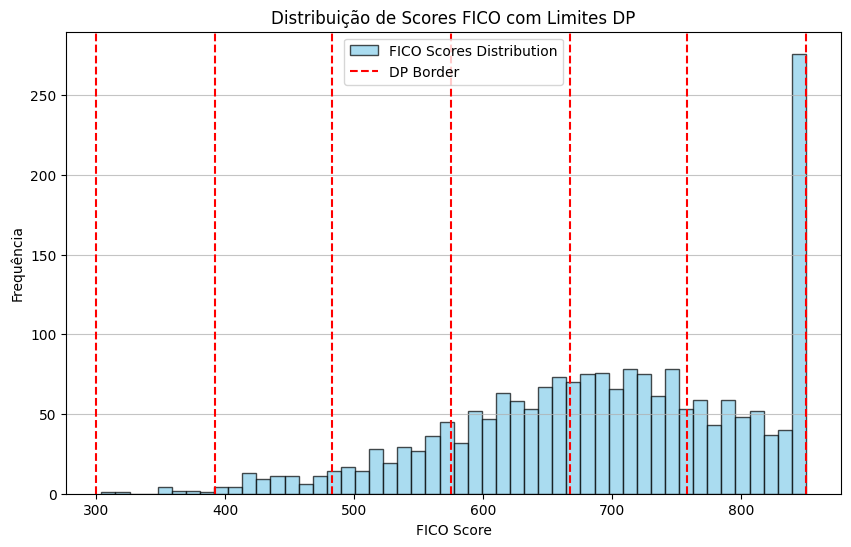

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fico' and 'borders_dp' are available from previous execution
# If not, you might need to re-run the simulation or ensure these variables are in scope

plt.figure(figsize=(10, 6))
plt.hist(fico, bins=50, color='skyblue', edgecolor='black', alpha=0.7, label='FICO Scores Distribution')

for border in borders_dp:
    plt.axvline(border, color='red', linestyle='--', linewidth=1.5, label='DP Border' if border == borders_dp[0] else "")

plt.title('Distribuição de Scores FICO com Limites DP')
plt.xlabel('FICO Score')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()